# **Uygulama: Gelişmiş Transformer Modelleri Oluşturma**

Bu uygulamada, Keras kullanarak gelişmiş Transformer modellerini hayata geçirecek ve bunlarla deneyler yapacaksınız. 

**Öğrenim hedefleri:** 

Bu uygulamanın sonunda şunları yapabileceksiniz:

- Transformer mimarisinin temel bileşenlerini anlayabileceksiniz.
- Sıfırdan çok başlıklı öz-dikkat mekanizması uygulayabileceksiniz.
- Zaman serisi tahmini için bir Transformer'ı eğitebilecek ve değerlendirebileceksiniz.
- Zaman serisi verilerinin ön işleme ve ölçeklendirme işlemlerini etkili bir şekilde gerçekleştirebileceksiniz.



## Transformer Nedir?

Transformer mimarisi, *“Attention Is All You Need”* başlıklı makalede tanıtılmıştır. Tekrarlama yerine dikkat mekanizmalarını kullanarak doğal dil işleme alanında devrim yaratmıştır.

### Temel Bileşenler:
- **Giriş Gömülmesi:** Giriş belirteçlerini (veya zaman adımlarını) vektörlere dönüştürür.
- **Konumsal Kodlama:** Giriş tokenlerinin konumu hakkında bilgi ekler.
- **Çok Başlı Öz Dikkat:** Modelin giriş dizisinin farklı kısımlarına odaklanmasını sağlar.
- **İleri Besleme Katmanları:** Dikkat edilen bilgileri işler.
- **Katman Normalleştirme ve Artık Bağlantılar:** Eğitimi stabilize eder ve hızlandırır.

> Transformers artık sadece NLP'de değil, zaman serisi tahmininde, görüntü tanıma ve daha birçok alanda yaygın olarak kullanılmaktadır.

**Sonraki:** Bu mimarinin bazı kısımlarını adım adım uygulayacaksınız.





## Adım Adım Talimatlar: 

### Adım 1: Gerekli kütüphaneleri içe aktarın 

Başlamadan önce, gerekli kütüphaneleri içe aktarmanız gerekir: TensorFlow ve Keras. Keras, TensorFlow içinde `tensorflow.keras.` olarak bulunur.


In [1]:
%pip install tensorflow pyarrow 
%pip install pandas  
%pip install scikit-learn 
%pip install matplotlib 
%pip install requests



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 40.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 39.1 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 1

In [3]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
import requests
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout

####  Sentetik hisse senedi fiyat verileri oluşturmak için ortamı hazırlayın


In [7]:
import numpy as np  # Sayısal işlemler için NumPy'yi içe aktar
import pandas as pd  # Veri işleme için pandas'ı içe aktar

# Sentetik hisse senedi fiyatı veri kümesi oluştur
np.random.seed(42)  # Tekrarlanabilirlik için rastgele tohum ayarla
data_length = 2000  # Veri noktalarının sayısını tanımla
trend = np.linspace(100, 200, data_length)  # 100'den 200'e doğrusal bir eğilim oluştur
noise = np.random.normal(0, 2, data_length)  # Ortalama 0 ve standart sapma 2 olan rastgele gürültü üret
synthetic_data = trend + noise  # Hisse senedi fiyatlarını simüle etmek için trend ve gürültüyü birleştir

# Bir DataFrame oluştur ve ‘stock_prices.csv’ olarak kaydet
data = pd.DataFrame(synthetic_data, columns=["Close"])  # Diziyi ‘Close’ sütunlu bir DataFrame'e dönüştür
data.to_csv('stock_prices.csv', index=False)  # DataFrame'i indeks olmadan CSV olarak kaydet
print("Synthetic stock_prices.csv oluşturuldu ve yüklendi.")  # Onay mesajını yazdır

Synthetic stock_prices.csv oluşturuldu ve yüklendi.


In [8]:
# Veri setini yükle
data = pd.read_csv('stock_prices.csv')  # CSV dosyasını oku
data = data[['Close']].values  # Sadece 'Close' sütununu al ve numpy array’e çevir

# Veriyi normalize et
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))  # 0-1 aralığına ölçeklendirici oluştur
data = scaler.fit_transform(data)  # Veriyi normalize et

# Model için veriyi hazırla
def create_dataset(data, time_step=1):
    X, Y = [], []

    for i in range(len(data)-time_step-1):
        a = data[i:(i+time_step), 0]  # Zaman adımı kadar geçmiş değerleri al
        X.append(a)  # Giriş dizisine ekle
        Y.append(data[i + time_step, 0])  # Hedef değer olarak sonraki zamanı ekle
    return np.array(X), np.array(Y)

time_step = 100  # Kullanılacak zaman adımı sayısı
X, Y = create_dataset(data, time_step)  # X ve Y dizilerini oluştur
X = X.reshape(X.shape[0], X.shape[1], 1)  # LSTM için 3 boyutlu hale getir

print("Shape of X:", X.shape)  # X’in boyutunu yazdır
print("Shape of Y:", Y.shape)  # Y’nin boyutunu yazdır

Shape of X: (1899, 100, 1)
Shape of Y: (1899,)


Yukarıdaki kodda: 

`tensorflow`, Python'da makine öğrenimi için kullanılan ana kütüphanedir.  

`stock_prices.csv`, yüklenen veri kümesidir. 

`MinMaxScaler` yöntemi, verileri normalleştirmek için kullanılır.  

`create_dataset` yöntemi, verileri eğitim için hazırlamak amacıyla kullanılır. 

### 2. Adım: Çok Başlı Öz Dikkat Mekanizmasını Uygulama 

Çok Başlı Öz Dikkat mekanizmasını tanımlayın. 

In [9]:
class MultiHeadSelfAttention(Layer): 
    # Çoklu başlı kendi kendine dikkat (Multi-Head Self-Attention) katmanı

    def __init__(self, embed_dim, num_heads=8): 
        # Katmanı başlatır ve gerekli Dense katmanlarını oluşturur
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim  # Gömme boyutu (embedding dimension)
        self.num_heads = num_heads  # Dikkat başlığı sayısı
        self.projection_dim = embed_dim // num_heads  # Her başlığa düşen boyut
        self.query_dense = Dense(embed_dim)  # Query (sorgu) ağı
        self.key_dense = Dense(embed_dim)    # Key (anahtar) ağı
        self.value_dense = Dense(embed_dim)  # Value (değer) ağı
        self.combine_heads = Dense(embed_dim)  # Başlıkları birleştirme ağı

    def attention(self, query, key, value): 
        # Verilen query, key ve value ile dikkat skorlarını hesaplar ve ağırlıklı çıktıyı döndürür
        score = tf.matmul(query, key, transpose_b=True)  # Q*K^T ile skor hesapla
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)  # Key boyutunu al
        scaled_score = score / tf.math.sqrt(dim_key)  # Skoru ölçeklendir
        weights = tf.nn.softmax(scaled_score, axis=-1)  # Softmax ile ağırlıkları hesapla
        output = tf.matmul(weights, value)  # Ağırlıklı değerleri çarp
        return output, weights  # Dikkatli çıktıyı ve ağırlıkları döndür

    def split_heads(self, x, batch_size): 
        # Tensor’ü başlıklar (heads) için yeniden şekillendirir ve boyutları değiştirir
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))  # Başlıkları ayır
        return tf.transpose(x, perm=[0, 2, 1, 3])  # Boyutları [batch, heads, seq_len, proj_dim] olarak değiştir

    def call(self, inputs): 
        # Katmanın ana fonksiyonu; girdi verisini alır, multi-head self-attention uygular ve çıktıyı döndürür
        batch_size = tf.shape(inputs)[0]  # Batch boyutunu al
        query = self.query_dense(inputs)  # Query vektörünü hesapla
        key = self.key_dense(inputs)      # Key vektörünü hesapla
        value = self.value_dense(inputs)  # Value vektörünü hesapla
        query = self.split_heads(query, batch_size)  # Query’i başlıklara ayır
        key = self.split_heads(key, batch_size)      # Key’i başlıklara ayır
        value = self.split_heads(value, batch_size)  # Value’yi başlıklara ayır
        attention, _ = self.attention(query, key, value)  # Dikkat hesapla
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])  # Başlıkları tekrar sıraya getir
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))  # Başlıkları birleştir
        output = self.combine_heads(concat_attention)  # Birleştirilmiş çıktıyı Dense ile geçir
        return output  # Sonuç çıktıyı döndür

Yukarıdaki kodda: 

- MultiHeadSelfAttention katmanı, modelin girdi dizisinin farklı kısımlarına aynı anda odaklanmasını sağlayan çok başlı öz-dikkat mekanizmasını uygular. 

- attention parametresi, dikkat puanlarını ve değerlerin ağırlıklı toplamını hesaplar. 

- split_heads parametresi, paralel dikkat hesaplaması için girdiyi birden fazla başlığa böler. 

- call yöntemi, öz-dikkat mekanizmasını uygular ve başlıkları birleştirir. 

### 3. Adım: Transformer bloğunu ekleyin 

Transformer bloğunu tanımlayın. 

In [10]:
class TransformerBlock(Layer): 
    # Tek bir Transformer bloğunu tanımlar: Multi-Head Attention + Feed-Forward + LayerNorm + Dropout

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        # Transformer bloğunu başlatır, dikkat katmanını, feed-forward ağını, layer norm ve dropout’ları oluşturur
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)  # Multi-head self-attention katmanı
        self.ffn = tf.keras.Sequential([  # Feed-forward ağı
            Dense(ff_dim, activation="relu"),  # Ara katman ReLU aktivasyonlu
            Dense(embed_dim),  # Çıkış katmanı embed boyutuna eşit
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6)  # İlk layer normalization
        self.layernorm2 = LayerNormalization(epsilon=1e-6)  # İkinci layer normalization
        self.dropout1 = Dropout(rate)  # İlk dropout
        self.dropout2 = Dropout(rate)  # İkinci dropout

    def call(self, inputs, training): 
        # Girdi verisini alır, self-attention ve feed-forward işlemlerini uygular, layer norm ve residual bağlantılar ile çıktıyı döndürür
        attn_output = self.att(inputs)  # Multi-head attention çıktısı
        attn_output = self.dropout1(attn_output, training=training)  # Dropout uygula
        out1 = self.layernorm1(inputs + attn_output)  # Residual bağlantı + layer normalization
        ffn_output = self.ffn(out1)  # Feed-forward ağ çıktısı
        ffn_output = self.dropout2(ffn_output, training=training)  # Dropout uygula
        return self.layernorm2(out1 + ffn_output)  # Son residual bağlantı + layer normalization, final çıktı

Yukarıdaki kodda:

- TransformerBlock katmanı, çok başlı öz-dikkat mekanizmasını ileri beslemeli bir sinir ağı ve normalleştirme katmanlarıyla birleştirir.  

- Aşırı uyumlanmayı önlemek için dropout kullanılır. 

- call yöntemi, öz-dikkat mekanizmasını uygular; ardından kalıntı bağlantıları ve katman normalleştirmesi içeren ileri beslemeli ağ devreye girer.

### 4. Adım: Kodlayıcı Katmanını Uygulama 

Kodlayıcı katmanını tanımlayın. 

In [11]:
class EncoderLayer(Layer): 
    
    # Transformer encoder katmanı: Multi-Head Self-Attention + Feed-Forward + LayerNorm + Dropout

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        # Encoder katmanını başlatır ve gerekli attention, feed-forward, layer norm ve dropout bileşenlerini oluşturur
        super(EncoderLayer, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)  # Multi-head self-attention katmanı
        self.ffn = tf.keras.Sequential([  # Feed-forward ağı
            Dense(ff_dim, activation="relu"),  # Ara katman ReLU aktivasyonlu
            Dense(embed_dim),  # Çıkış katmanı embed boyutuna eşit
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6)  # İlk layer normalization
        self.layernorm2 = LayerNormalization(epsilon=1e-6)  # İkinci layer normalization
        self.dropout1 = Dropout(rate)  # İlk dropout
        self.dropout2 = Dropout(rate)  # İkinci dropout

    def call(self, inputs, training): 
        # Girdi verisini alır, attention ve feed-forward işlemlerini uygular, residual bağlantı ve layer norm ile çıktıyı döndürür
        attn_output = self.att(inputs)  # Multi-head attention çıktısı
        attn_output = self.dropout1(attn_output, training=training)  # Dropout uygula
        out1 = self.layernorm1(inputs + attn_output)  # Residual bağlantı + layer normalization
        ffn_output = self.ffn(out1)  # Feed-forward ağı çıktısı
        ffn_output = self.dropout2(ffn_output, training=training)  # Dropout uygula
        return self.layernorm2(out1 + ffn_output)  # Son residual bağlantı + layer normalization, final çıktı

Yukarıdaki kodda: 

- EncoderLayer, TransformerBlock'a benzer ancak Transformer mimarisinde yeniden kullanılabilir bir katmandır. 

- Bir MultiHeadSelfAttention mekanizmasından ve bunu izleyen bir ileri beslemeli sinir ağından oluşur. 

- Her iki alt katmanın çevresinde kalıntı bağlantıları bulunur ve her bir alt katmanın çıktısına katman normalizasyonu uygulanır. 

- call yöntemi, kalıntı bağlantıları ve katman normalizasyonu ile birlikte, self-attention'ı ve ardından ileri beslemeli ağı uygular. 

### 5. Adım: Transformer kodlayıcısını uygulayın 

Transformer kodlayıcısını tanımlayın. 

In [12]:
import tensorflow as tf 
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout 

class MultiHeadSelfAttention(Layer): 
    def __init__(self, embed_dim, num_heads=8): 
        super(MultiHeadSelfAttention, self).__init__() 
        self.embed_dim = embed_dim 
        self.num_heads = num_heads 
        self.projection_dim = embed_dim // num_heads 
        self.query_dense = Dense(embed_dim) 
        self.key_dense = Dense(embed_dim) 
        self.value_dense = Dense(embed_dim) 
        self.combine_heads = Dense(embed_dim) 
 

    def attention(self, query, key, value): 
        score = tf.matmul(query, key, transpose_b=True) 
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32) 
        scaled_score = score / tf.math.sqrt(dim_key) 
        weights = tf.nn.softmax(scaled_score, axis=-1) 
        output = tf.matmul(weights, value) 
        return output, weights 


    def split_heads(self, x, batch_size): 
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim)) 
        return tf.transpose(x, perm=[0, 2, 1, 3]) 


    def call(self, inputs): 
        batch_size = tf.shape(inputs)[0] 
        query = self.query_dense(inputs) 
        key = self.key_dense(inputs) 
        value = self.value_dense(inputs) 
        query = self.split_heads(query, batch_size) 
        key = self.split_heads(key, batch_size) 
        value = self.split_heads(value, batch_size) 
        attention, _ = self.attention(query, key, value) 
        attention = tf.transpose(attention, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim)) 
        output = self.combine_heads(concat_attention) 
        return output 

class TransformerBlock(Layer): 
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerBlock, self).__init__() 
        self.att = MultiHeadSelfAttention(embed_dim, num_heads) 
        self.ffn = tf.keras.Sequential([ 
            Dense(ff_dim, activation="relu"), 
            Dense(embed_dim), 
        ]) 

        self.layernorm1 = LayerNormalization(epsilon=1e-6) 
        self.layernorm2 = LayerNormalization(epsilon=1e-6) 
        self.dropout1 = Dropout(rate) 
        self.dropout2 = Dropout(rate) 
 

    def call(self, inputs, training): 
        attn_output = self.att(inputs) 
        attn_output = self.dropout1(attn_output, training=training) 
        out1 = self.layernorm1(inputs + attn_output) 
        ffn_output = self.ffn(out1) 
        ffn_output = self.dropout2(ffn_output, training=training) 
        return self.layernorm2(out1 + ffn_output) 

class TransformerEncoder(Layer): 
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1): 
        super(TransformerEncoder, self).__init__() 
        self.num_layers = num_layers 
        self.embed_dim = embed_dim 
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate) for _ in range(num_layers)] 
        self.dropout = Dropout(rate) 

    def call(self, inputs, training=False): 
        x = inputs 
        for i in range(self.num_layers): 
            x = self.enc_layers[i](x, training=training) 
        return x 

# Example usage 
embed_dim = 128 
num_heads = 8 
ff_dim = 512 
num_layers = 4 

transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim) 
inputs = tf.random.uniform((1, 100, embed_dim)) 
outputs = transformer_encoder(inputs, training=False)  # Use keyword argument for 'training' 
print(outputs.shape)  # Should print (1, 100, 128) 

E0000 00:00:1774718616.857871     299 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(1, 100, 128)


Yukarıdaki kodda: 

TransformerEncoder, Transformer mimarisinin kodlama kısmını gerçekleştiren birden fazla TransformerBlock katmanından oluşur. 

### 6. Adım: Transformer modelini oluşturun ve derleyin 

Transformer Kodlayıcıyı sıralı veriler için eksiksiz bir modele entegre edin. 

In [13]:
# Gerekli parametreleri tanımla
embed_dim = 128  # Gömme boyutu (embedding dimension)
num_heads = 8    # Multi-head attention başlık sayısı
ff_dim = 512     # Feed-forward ağın ara katman boyutu
num_layers = 4   # Encoder katmanı sayısı

# Transformer Encoder'ı tanımla
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim)  # Encoder katmanlarını oluştur

# Modeli oluştur
input_shape = (X.shape[1], X.shape[2])  # Girdi şekli (time_step, 1)
inputs = tf.keras.Input(shape=input_shape)  # Input katmanı

# Girdiyi embed_dim boyutuna dönüştür
x = tf.keras.layers.Dense(embed_dim)(inputs)  # Dense ile embedding boyutuna projeksiyon
encoder_outputs = transformer_encoder(x)  # Transformer Encoder’dan çıktı al
flatten = tf.keras.layers.Flatten()(encoder_outputs)  # Çıktıyı düzleştir
outputs = tf.keras.layers.Dense(1)(flatten)  # Tek değerli tahmin çıktısı (ör. stock price)

# Modeli oluştur
model = tf.keras.Model(inputs, outputs)  # Keras Model objesi

# Modeli derle
model.compile(optimizer='adam', loss='mse')  # Optimizatör: Adam, Kayıp: Mean Squared Error

# Model özetini yazdır
model.summary()  # Model katmanları ve parametre sayısı

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100, 128)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 100, 128)       │       793,088 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,145 (3.08 MB)

 Trainable params: 806,145 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

Yukarıdaki kodda: 

- Transformer Encoder modeli gerekli parametreleri tanımlar, çıktıyı düzleştirir ve nihai çıktıyı üretmek üzere bir yoğun katmanla son bulur.  

- Model daha sonra Adam optimizörü ve ortalama karesel hata kayıpları ile derlenir. 

### Step 7: Train the Transformer model 

Train the model on the prepared dataset. 


In [14]:
# Train the model
model.fit(X, Y, epochs=20, batch_size=32)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - loss: 3.8583  
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.2056 
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.2096 
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.1527 
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1492 
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1560
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1255 
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - loss: 0.1227 
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1191 
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - loss: 0.1394 
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1407
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1322 
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0761 
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0786 
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0721 
Epoch

In the above code: 

The model is trained on the normalized stock price data for 20 epochs with a batch size of 32. 


### Step 8: Evaluate and Make Predictions 

Evaluate the model's performance and make predictions on the dataset. 


60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/step


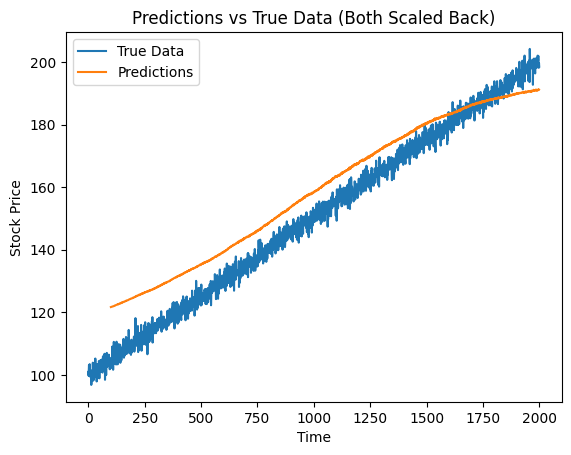

In [15]:
# Make predictions 
predictions = model.predict(X) 
predictions = scaler.inverse_transform(predictions) 

# Prepare true values for comparison
true_values = scaler.inverse_transform(data.reshape(-1, 1))

# Plot the predictions vs true values
import matplotlib.pyplot as plt 

plt.plot(true_values, label='True Data') 
plt.plot(np.arange(time_step, time_step + len(predictions)), predictions, label='Predictions') 
plt.xlabel('Time') 
plt.ylabel('Stock Price') 
plt.legend() 
plt.title('Predictions vs True Data (Both Scaled Back)')
plt.show() 


Yukarıdaki kodda: 

- Modelin tahminleri, ölçeklendiricinin ters dönüşümü kullanılarak orijinal ölçeğe geri dönüştürülür. 

- Modelin performansını görselleştirmek için gerçek veriler ve tahminler grafiğe işlenir. 

## Alıştırmalar: 

 ### Alıştırma 1: Transformer modeline dropout ekleyin 

 **Amaç: Aşırı uyumlanmayı önlemek için Transformer modeline nasıl dropout katmanları ekleneceğini anlamak.** 

 Talimatlar: 

- Modeldeki Flatten katmanından sonra bir dropout katmanı ekleyin. 

- Dropout oranını 0,5 olarak ayarlayın. 

In [16]:
from tensorflow.keras.layers import Dropout 
# Add a dropout layer after the Flatten layer 
flatten = tf.keras.layers.Flatten()(encoder_outputs) 
dropout = Dropout(0.5)(flatten) 
outputs = tf.keras.layers.Dense(1)(dropout) 
# Build the model 

model = tf.keras.Model(inputs, outputs) 
# Compile the model 

model.compile(optimizer='adam', loss='mse') 
# Train the model 

model.fit(X, Y, epochs=20, batch_size=32) 

# Evaluate the model 

loss = model.evaluate(X, Y) 

print(f'Test loss: {loss}') 


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 3.3120  
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 1.1687 
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.5760 
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.2776 
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.1163 
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0762 
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0564 
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0449 
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0353
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0295 
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0289 
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0281 
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0282 
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0205 
Epoch 15/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0230 
Epoc